<a href="https://colab.research.google.com/github/pharmbri/Superkart/blob/main/Superkart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 22.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.34.0 which is incompatible.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.34.0 which is incompatible.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

In [ ]:
# Loading Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/SuperKart.csv'
df = pd.read_csv(file_path)
display(df.head())

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [ ]:
# Looking for missing values
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


In [ ]:
# Looking for duplicate values
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


**Exploratory Data Analysis**

### Univariate Analysis of Numerical Features

In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


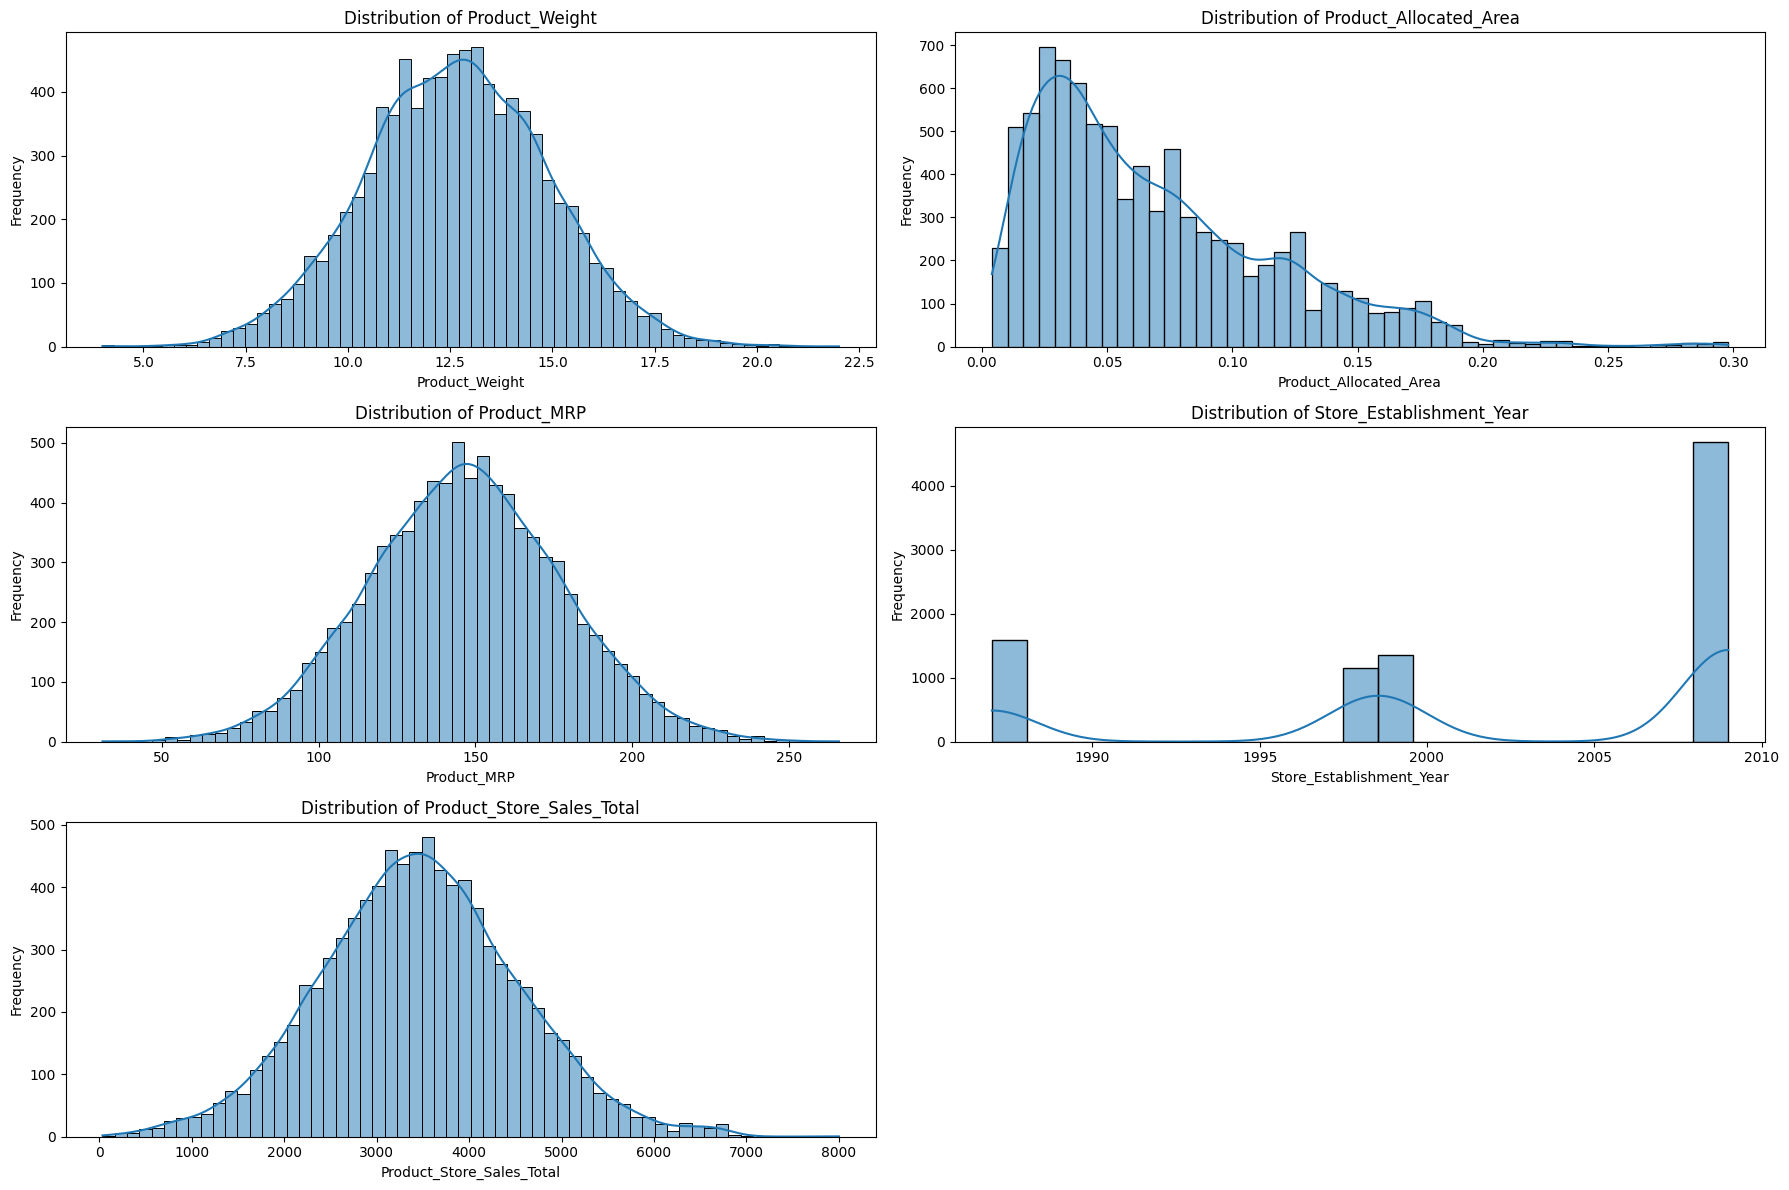

In [ ]:
numerical_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

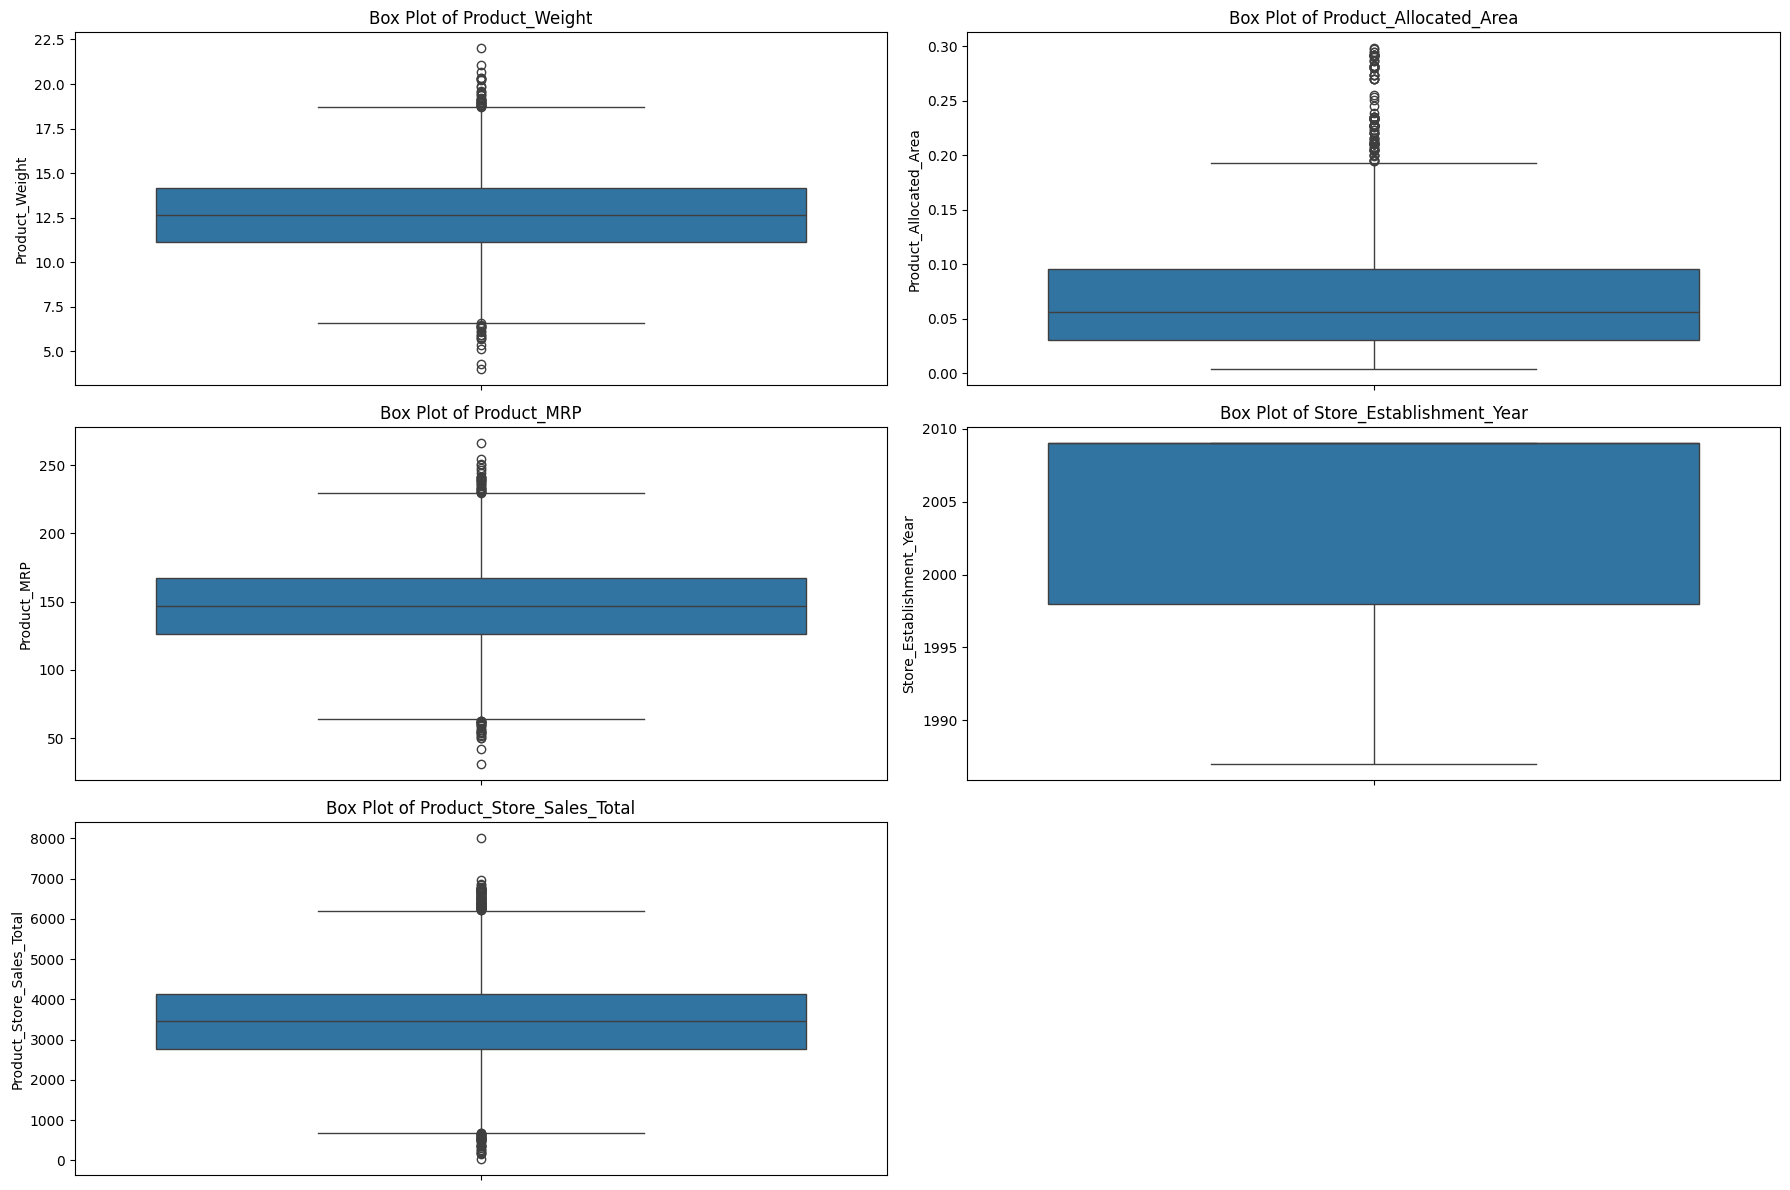

In [ ]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

for col in categorical_cols:
    print(f'\nValue counts for {col}:')
    display(df[col].value_counts())


Value counts for Product_Sugar_Content:


,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2251
No Sugar,1519
reg,108



Value counts for Product_Type:


,count
Product_Type,
Fruits and Vegetables,1249
Snack Foods,1149
Frozen Foods,811
Dairy,796
Household,740
Baking Goods,716
Canned,677
Health and Hygiene,628
Meat,618



Value counts for Store_Id:


...

,count
Store_Size,
Medium,6025
High,1586
Small,1152



Value counts for Store_Location_City_Type:


,count
Store_Location_City_Type,
Tier 2,6262
Tier 1,1349
Tier 3,1152



Value counts for Store_Type:


,count
Store_Type,
Supermarket Type2,4676
Supermarket Type1,1586
Departmental Store,1349
Food Mart,1152


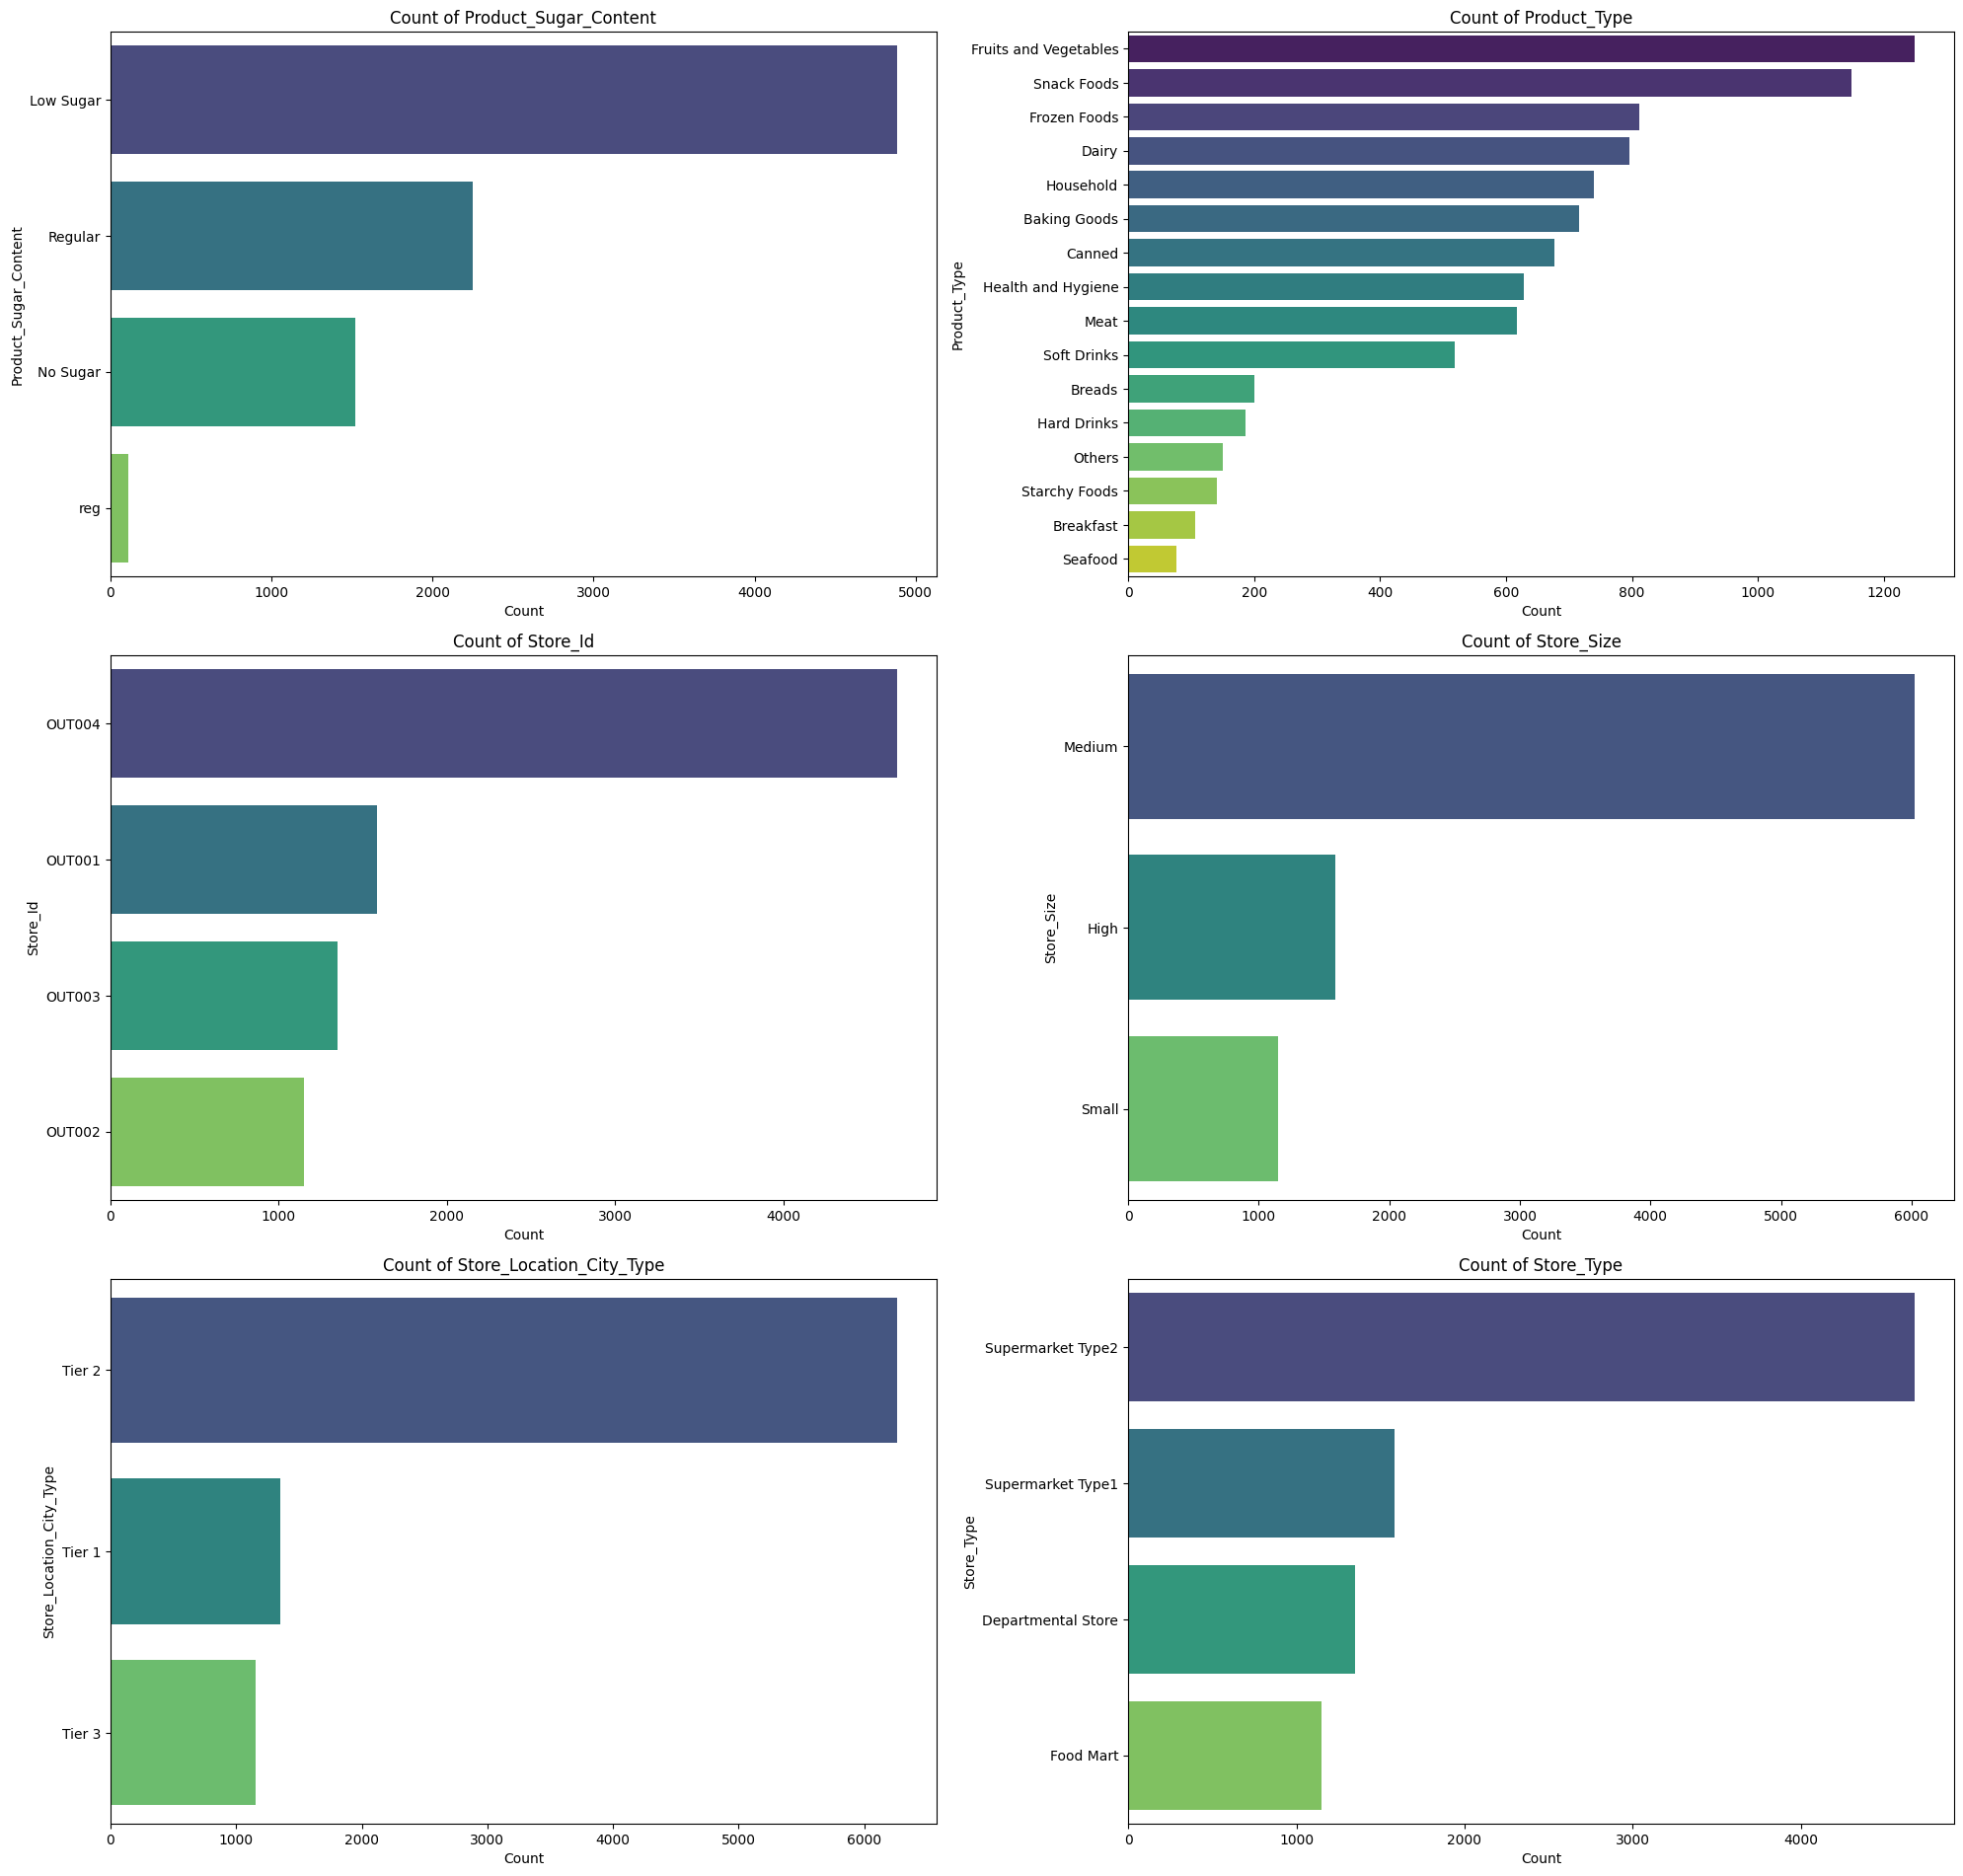

In [ ]:
plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i + 1)
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
df['Product_Sugar_Content'] = df['Product_Sugar_Content'].replace('reg', 'Regular')
print('\nUpdated Value counts for Product_Sugar_Content:')
display(df['Product_Sugar_Content'].value_counts())


Updated Value counts for Product_Sugar_Content:


,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


### Bivariate Analysis

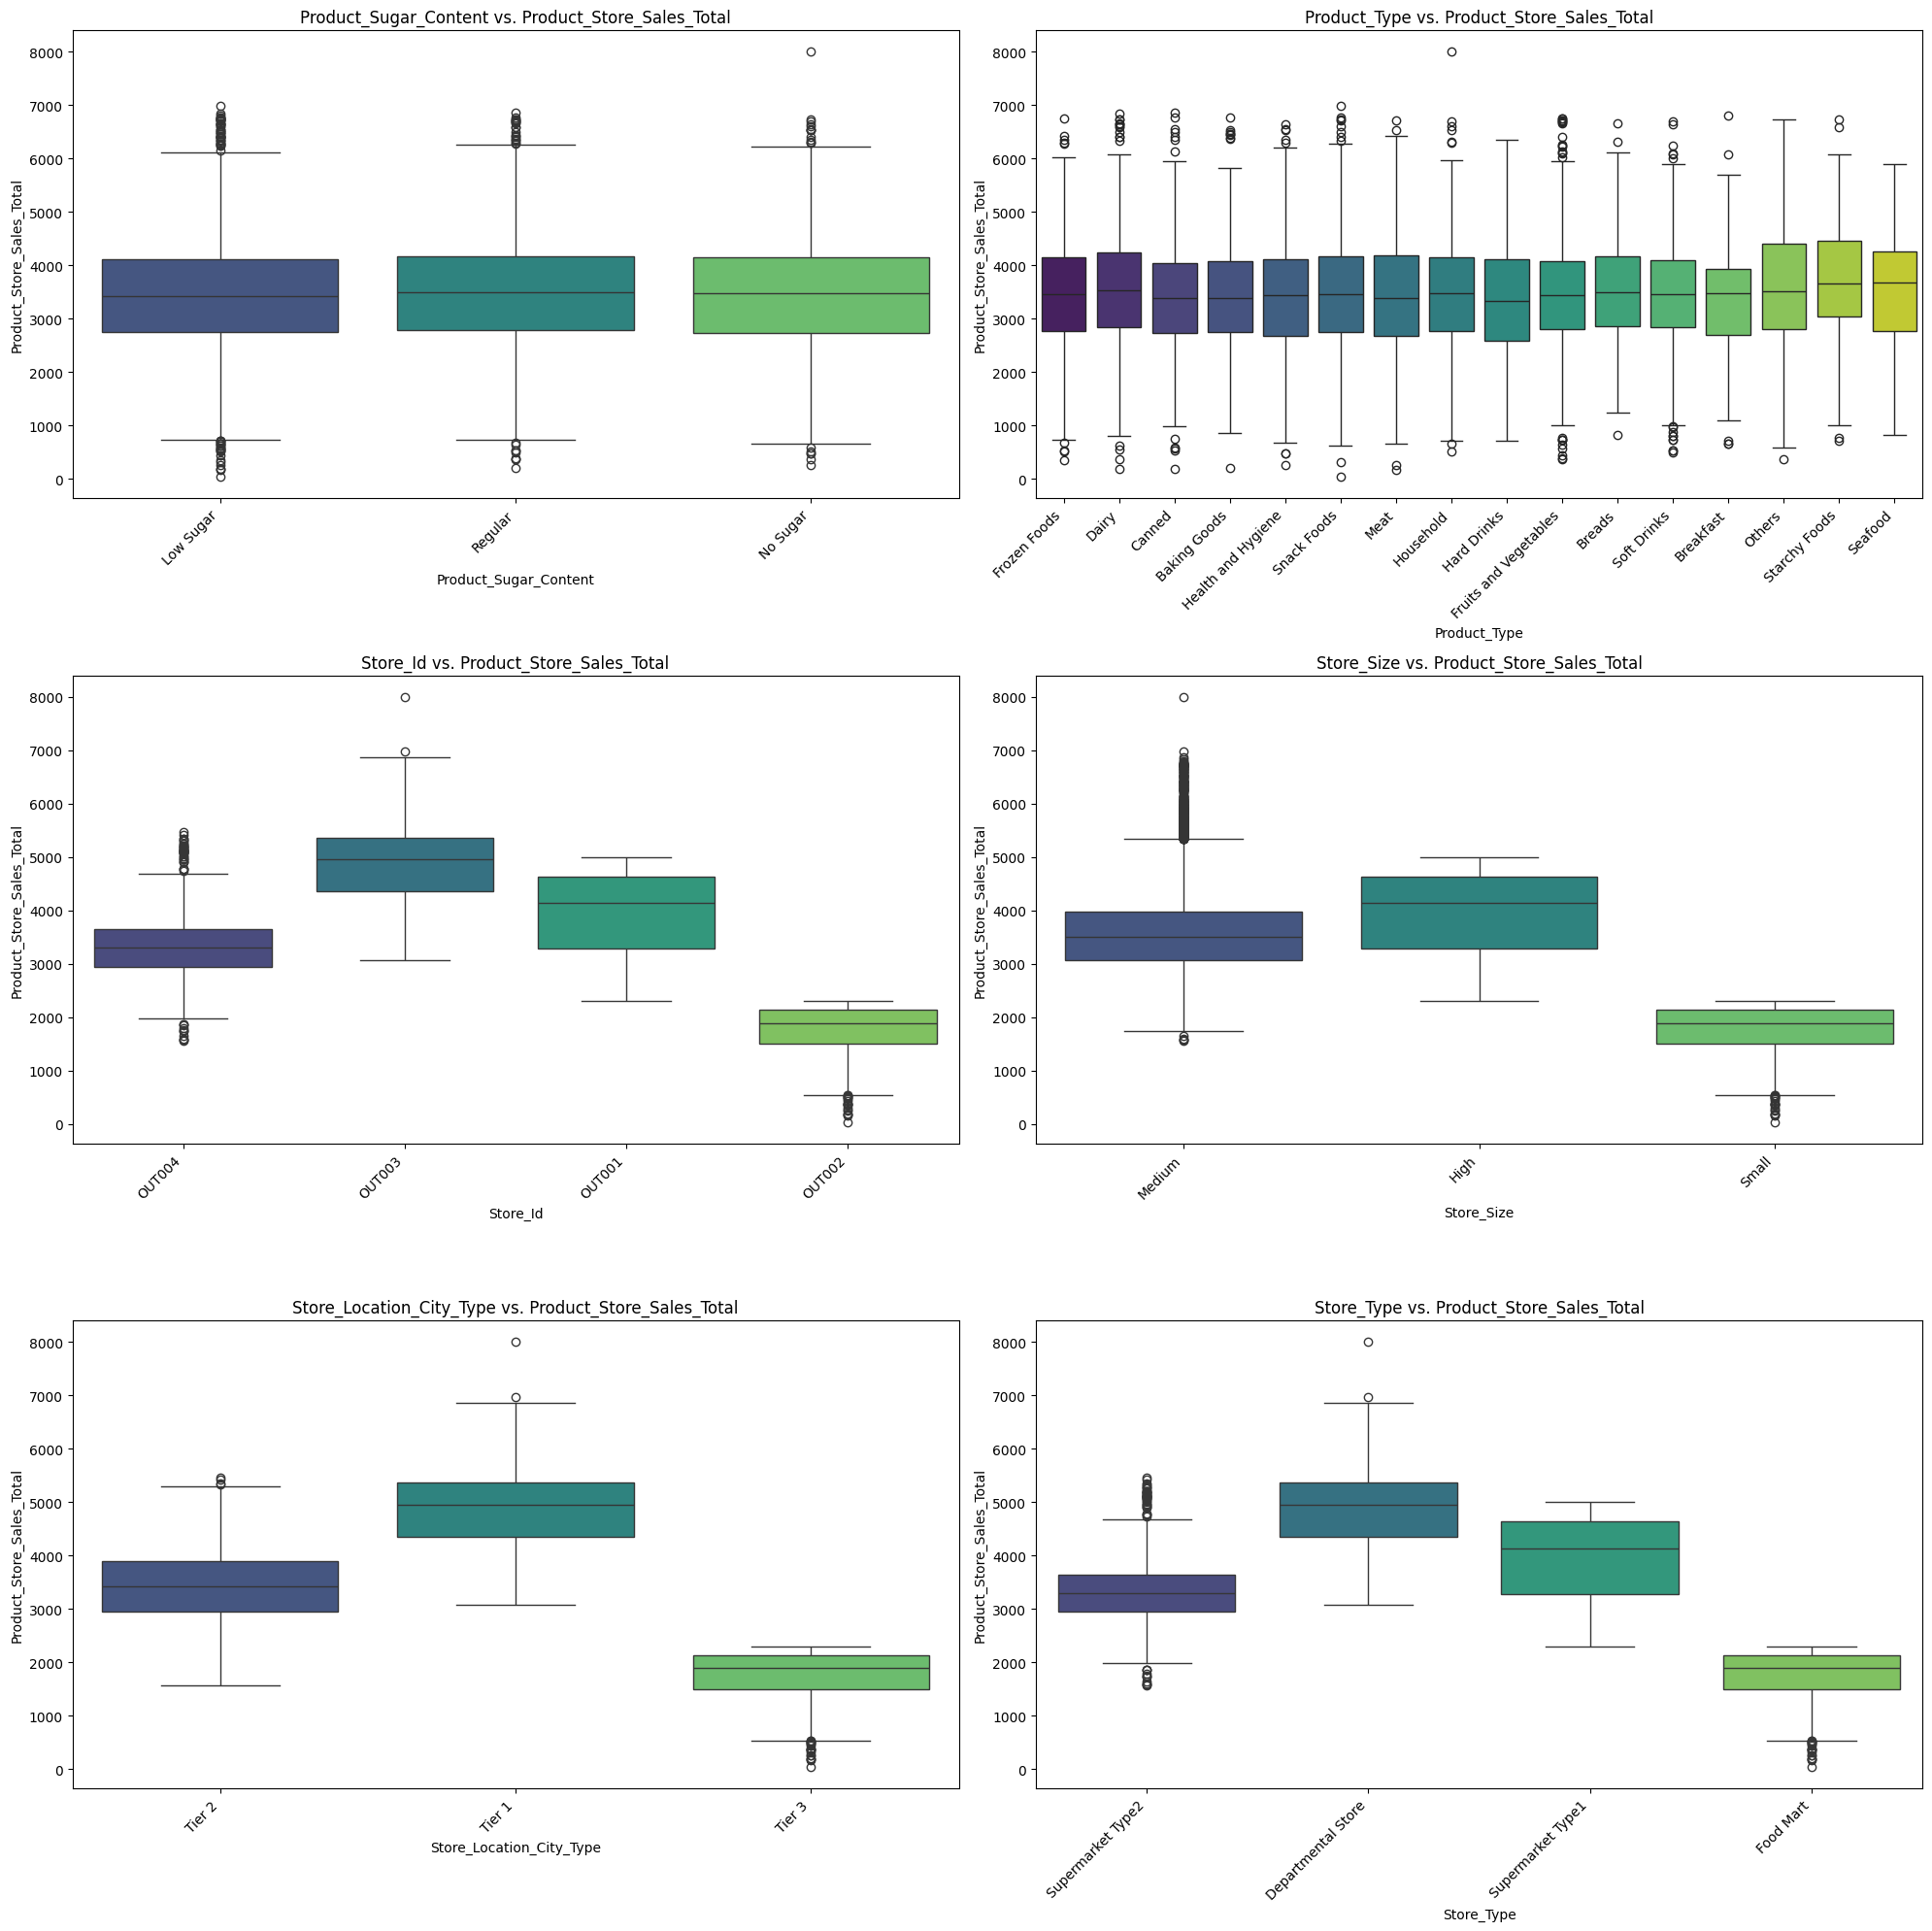

In [ ]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(data=df, x=col, y='Product_Store_Sales_Total', palette='viridis')
    plt.title(f'{col} vs. Product_Store_Sales_Total')
    plt.xlabel(col)
    plt.ylabel('Product_Store_Sales_Total')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bivariate Analysis

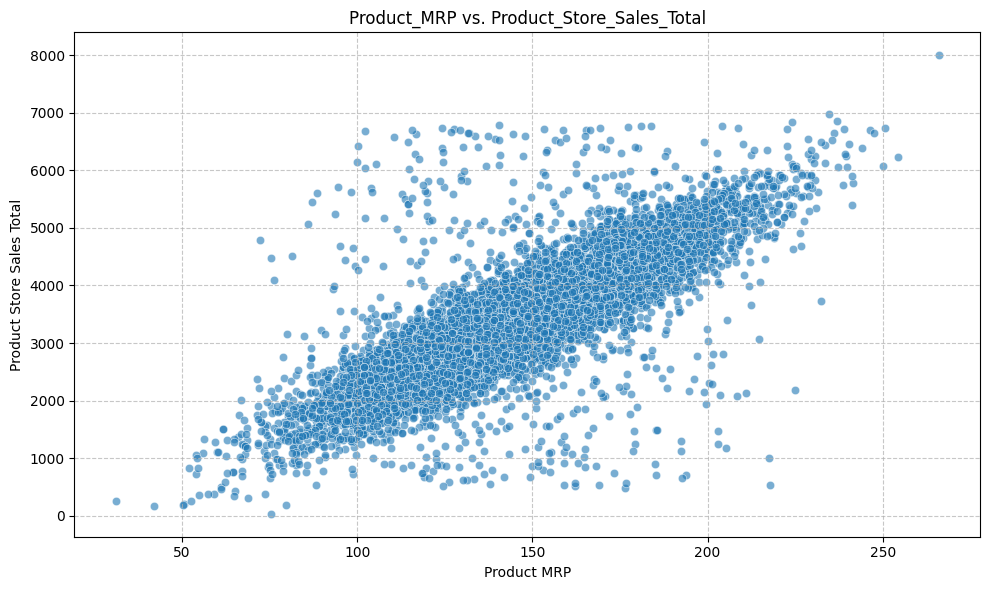

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Product_MRP', y='Product_Store_Sales_Total', alpha=0.6)
plt.title('Product_MRP vs. Product_Store_Sales_Total')
plt.xlabel('Product MRP')
plt.ylabel('Product Store Sales Total')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

# Display the correlation matrix
display(correlation_matrix)

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
Product_Weight,1.000000,0.014754,0.532716,-0.161907,0.737955
Product_Allocated_Area,0.014754,1.000000,-0.009508,0.004467,-0.000933
Product_MRP,0.532716,-0.009508,1.000000,-0.189357,0.787989
Store_Establishment_Year,-0.161907,0.004467,-0.189357,1.000000,-0.185027
Product_Store_Sales_Total,0.737955,-0.000933,0.787989,-0.185027,1.000000


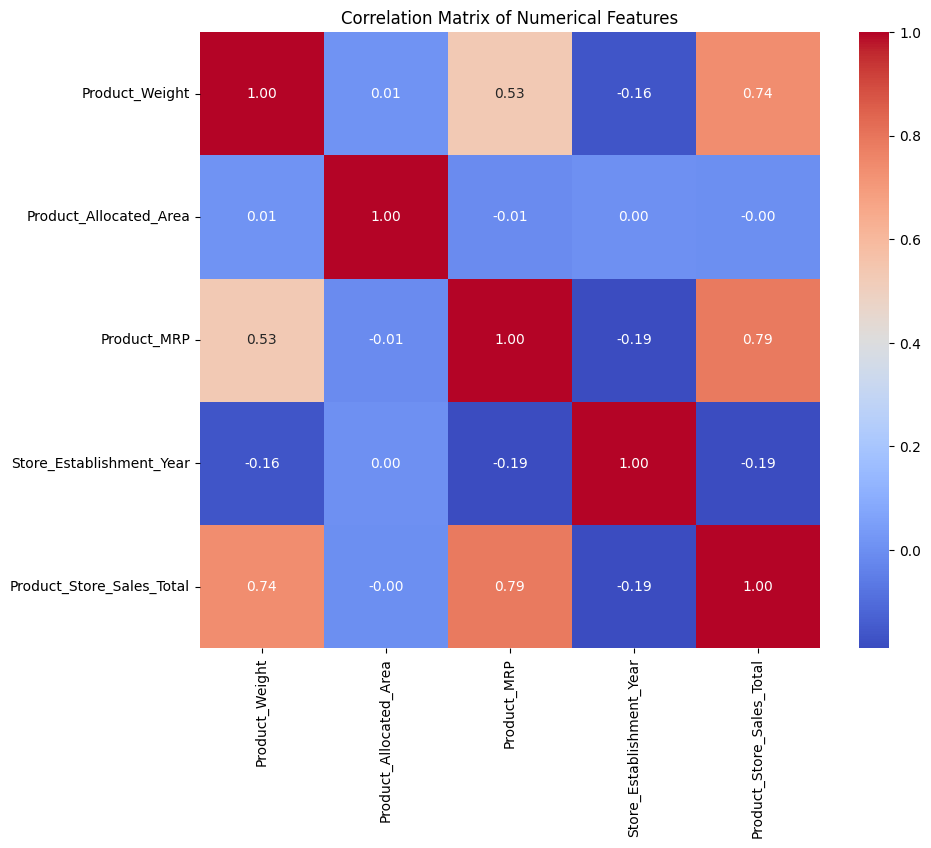

In [ ]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Data PreProcessing: Training and Testing Sets

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numerical and categorical features (excluding the target 'Product_Store_Sales_Total' and 'Product_Id')
numerical_features = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
categorical_features = ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        # OneHotEncoder will output dense by default since ColumnTransformer itself is set to dense
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop' # Drop any columns not specified
    # Removed sparse_output=False as it caused a TypeError
)

# First, fit the preprocessor on the training data (excluding target and ID)
data_to_process = df.drop(columns=['Product_Id', 'Product_Store_Sales_Total'])
preprocessor.fit(data_to_process)

# Then, transform the data
X_processed = preprocessor.transform(data_to_process)

# Get all feature names generated by the ColumnTransformer
all_feature_names = preprocessor.get_feature_names_out()

# Create df_encoded DataFrame
# Convert the sparse matrix X_processed to a dense array before creating the DataFrame
df_encoded = pd.DataFrame(X_processed.toarray(), columns=all_feature_names)

# Define features (X) and target (y)
X = df_encoded
y = df['Product_Store_Sales_Total'] # Target comes from original df

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (7010, 37)
Shape of X_test: (1753, 37)
Shape of y_train: (7010,)
Shape of y_test: (1753,)


In [ ]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
lin_reg_model = LinearRegression()

# Train the model on the training data
lin_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
y_pred = lin_reg_model.predict(X_test)
display(y_pred[:10])

array([3369.14648059, 3330.56448585, 3024.46016044, 1723.45393054,
       4406.29565867, 3024.2715451 , 3026.5565892 , 3207.09330885,
       3264.76135988, 1440.00637125])

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R-squared: {r2:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

R-squared: 0.8339
Mean Absolute Error (MAE): 256.60
Root Mean Squared Error (RMSE): 435.40


##Model Building

In [ ]:
 # function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

### Random Forest

In [ ]:
# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Display the first 10 predictions
display(y_pred_rf[:10])

array([3184.9896, 3365.4876, 2413.5405, 1898.7407, 4699.7026, 2913.1124,
       2865.0027, 3179.4782, 3340.0853, 1560.4583])

#### Evaluate Random Forest Performance

In [ ]:
# Get model performance metrics for the Random Forest model
rf_model_performance = model_performance_regression(rf_model, X_test, y_test)

# Display the performance metrics
display(rf_model_performance)

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.485559,109.04502,0.929568,0.928049,0.038852


### Gradient Boosting

In [ ]:
# Initialize the Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(random_state=42)

# Train the model on the training data
gb_model.fit(X_train, y_train)

print("Gradient Boosting Regressor model trained successfully.")

Gradient Boosting Regressor model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)

# Display the first 10 predictions
display(y_pred_gb[:10])

array([3455.22786544, 3406.77991814, 2512.40927679, 1914.83772882,
       4620.28532293, 2905.97935208, 2930.33484094, 3144.23148679,
       3304.61251955, 1578.35429469])

#### Evaluate Gradient Boosting Performance

In [ ]:
# Get model performance metrics for the Gradient Boosting model
gb_model_performance = model_performance_regression(gb_model, X_test, y_test)

# Display the performance metrics
display(gb_model_performance)

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.233289,146.489793,0.91565,0.913831,0.051974


### XGBoost

In [ ]:
# Initialize the XGBoost Regressor model
xgb_model = XGBRegressor(random_state=42)

# Train the model on the training data
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Display the first 10 predictions
display(y_pred_xgb[:10])

array([3393.3933, 3402.3574, 2404.2434, 1877.2814, 4719.982 , 2839.1694,
       3009.1506, 3139.8328, 3296.5303, 1597.7643], dtype=float32)

#### Evaluate XGBoost Regressor Performance

In [ ]:
# Get model performance metrics for the XGBoost model
xgb_model_performance = model_performance_regression(xgb_model, X_test, y_test)

# Display the performance metrics
display(xgb_model_performance)

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.109498,137.521286,0.915718,0.913899,0.050988


### Feature Importance Comparison

#### Random Forest Feature Importance

Top 10 Random Forest Feature Importances:


,Feature,Importance
2,num__Product_MRP,0.459742
0,num__Product_Weight,0.106936
29,cat__Store_Size_Small,0.065930
34,cat__Store_Type_Food Mart,0.050045
24,cat__Store_Id_OUT002,0.049177
32,cat__Store_Location_City_Type_Tier 3,0.042100
3,num__Store_Establishment_Year,0.037581
31,cat__Store_Location_City_Type_Tier 2,0.035348
30,cat__Store_Location_City_Type_Tier 1,0.027832
25,cat__Store_Id_OUT003,0.024206


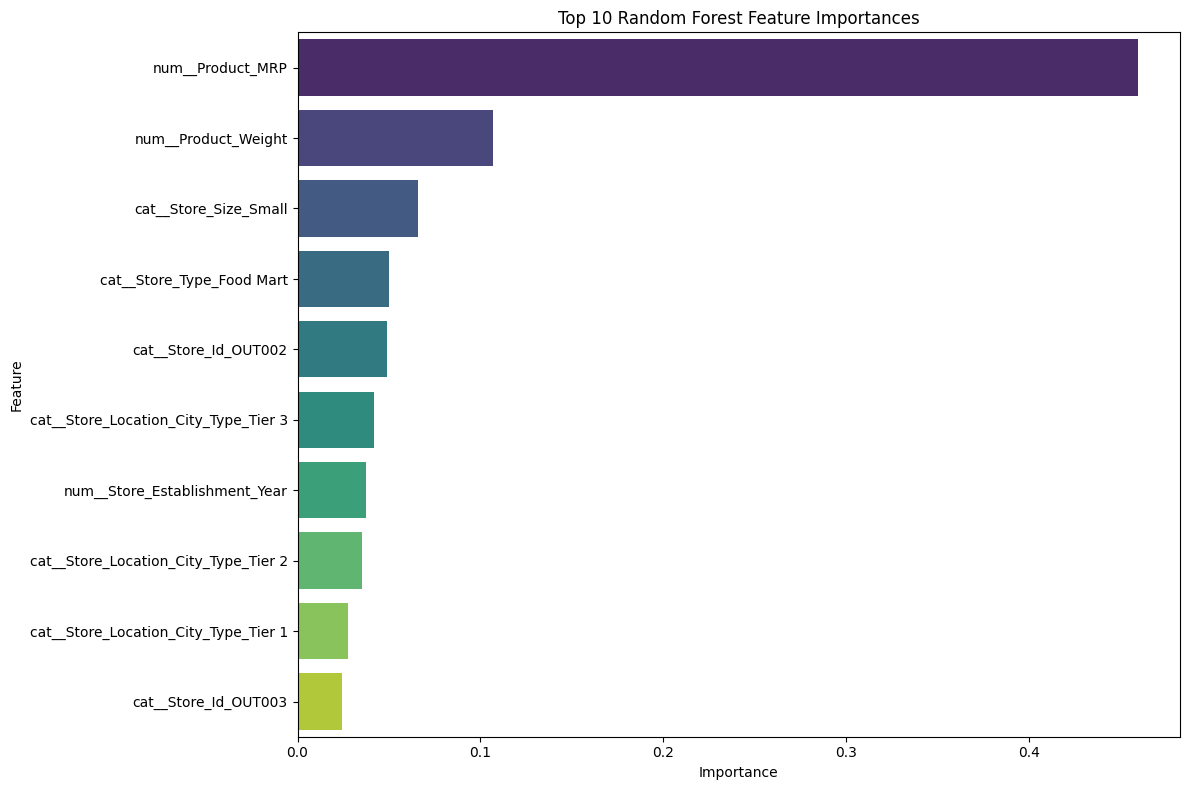

In [ ]:
# Get feature importances from the Random Forest model
rf_feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
rf_features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_feature_importances
})

# Sort features by importance in descending order
rf_features_df = rf_features_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print("Top 10 Random Forest Feature Importances:")
display(rf_features_df.head(10))

# Visualize the top 10 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_features_df.head(10), palette='viridis')
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### XGBoost Feature Importance

Top 10 XGBoost Feature Importances:


,Feature,Importance
24,cat__Store_Id_OUT002,0.395853
25,cat__Store_Id_OUT003,0.377654
3,num__Store_Establishment_Year,0.110287
2,num__Product_MRP,0.069690
0,num__Product_Weight,0.011402
11,cat__Product_Type_Dairy,0.002436
15,cat__Product_Type_Health and Hygiene,0.002357
5,cat__Product_Sugar_Content_No Sugar,0.002334
4,cat__Product_Sugar_Content_Low Sugar,0.002110
10,cat__Product_Type_Canned,0.002095


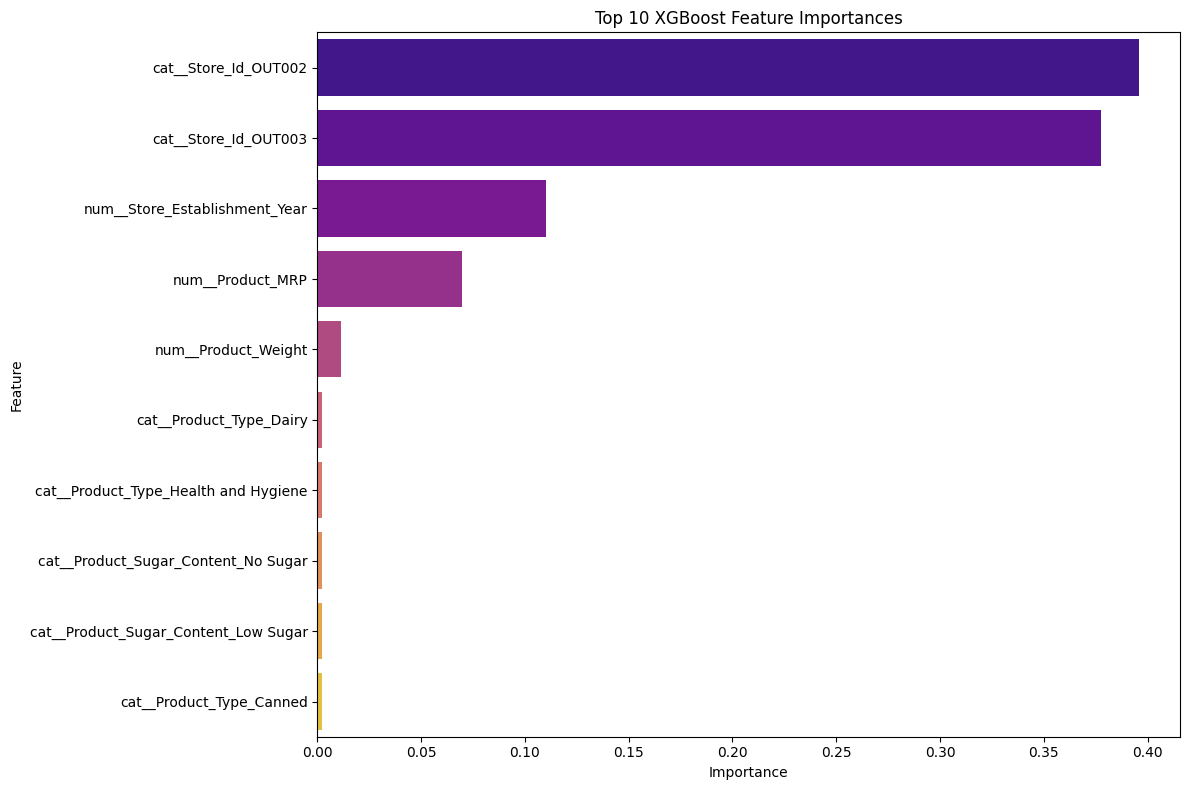

In [ ]:
# Get feature importances from the XGBoost model
xgb_feature_importances = xgb_model.feature_importances_

# Create a DataFrame for better visualization
xgb_features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_feature_importances
})

# Sort features by importance in descending order
xgb_features_df = xgb_features_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print("Top 10 XGBoost Feature Importances:")
display(xgb_features_df.head(10))

# Visualize the top 10 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_features_df.head(10), palette='plasma')
plt.title('Top 10 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

##Model Performance Improvement - Hyperparameter Tuning

In [ ]:
# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42), # Use the base Random Forest model
    param_grid=param_grid_rf,
    cv=3, # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=2, # Display progress
    scoring='neg_mean_squared_error' # Optimize for RMSE (negative MSE)
)

print("GridSearchCV for Random Forest Regressor initialized.")

GridSearchCV for Random Forest Regressor initialized.


In [35]:
grid_search_rf.fit(X_train, y_train)

print("GridSearchCV fitting complete.")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
GridSearchCV fitting complete.


In [36]:
# Get the best parameters
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Random Forest Regressor:", best_params_rf)

# Get the best estimator
best_rf_model = grid_search_rf.best_estimator_
print("Best Random Forest model obtained.")

Best parameters for Random Forest Regressor: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best Random Forest model obtained.


In [37]:
# Make predictions with the best Random Forest model
y_pred_rf_tuned = best_rf_model.predict(X_test)

# Display the first 10 predictions from the tuned model
display(y_pred_rf_tuned[:10])

array([3260.3264277 , 3362.35879108, 2411.87408301, 1898.26469115,
       4674.70537125, 2931.93360204, 2863.29106838, 3186.56590495,
       3280.57623155, 1558.26231134])

#### Evaluate Tuned Random Forest Regressor Performance

In [38]:
# Get model performance metrics for the tuned Random Forest model
rf_tuned_model_performance = model_performance_regression(best_rf_model, X_test, y_test)

# Display the performance metrics
display(rf_tuned_model_performance)

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,277.247417,104.591603,0.932634,0.93118,0.037489


In [39]:
# Concatenate all model performance dataframes
all_model_performance = pd.concat(
    [rf_model_performance.rename(index={0: 'Random Forest (Untuned)'}),
     gb_model_performance.rename(index={0: 'Gradient Boosting (Untuned)'}),
     xgb_model_performance.rename(index={0: 'XGBoost (Untuned)'}),
     rf_tuned_model_performance.rename(index={0: 'Random Forest (Tuned)'})]
)

# Display the combined performance metrics, sorted by R-squared for easy comparison
display(all_model_performance.sort_values(by='R-squared', ascending=False))

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
Random Forest (Tuned),277.247417,104.591603,0.932634,0.931180,0.037489
Random Forest (Untuned),283.485559,109.045020,0.929568,0.928049,0.038852
XGBoost (Untuned),310.109498,137.521286,0.915718,0.913899,0.050988
Gradient Boosting (Untuned),310.233289,146.489793,0.915650,0.913831,0.051974


## Final Model Selection

Based on the comprehensive evaluation of all models, here are the key findings:

**Random Forest (Tuned)** emerged as the best-performing model, demonstrating the highest predictive accuracy with an R-squared of 0.9326 and the lowest RMSE of 277.25 and MAE of 104.59.

**Hyperparameter tuning ** significantly improved the Random Forest model's performance, increasing its R-squared from 0.9296 (untuned) to 0.9326 (tuned).

**Untuned Random Forest model** was already a strong performer, outperforming both Gradient Boosting and XGBoost before tuning.
XGBoost and Gradient Boosting models showed comparable performance to each other, but both were outperformed by the Random Forest models, both untuned and tuned.

*In conclusion, the hyperparameter-tuned Random Forest Regressor is the most robust and accurate model for predicting Product_Store_Sales_Total among the ones evaluated.*

## Serialization

### Saving the Model and Preprocessor

In [41]:
# Define file paths for the model, preprocessor, and feature names
model_filename = 'tuned_random_forest_model.joblib'
preprocessor_filename = 'preprocessor.joblib'
feature_names_filename = 'all_feature_names.joblib'

# Save the best Random Forest model
joblib.dump(best_rf_model, model_filename)
print(f"Model saved to {model_filename}")

# Save the preprocessor
joblib.dump(preprocessor, preprocessor_filename)
print(f"Preprocessor saved to {preprocessor_filename}")

# Save the all_feature_names array
joblib.dump(all_feature_names, feature_names_filename)
print(f"All feature names saved to {feature_names_filename}")

Model saved to tuned_random_forest_model.joblib
Preprocessor saved to preprocessor.joblib
All feature names saved to all_feature_names.joblib


### Making Predictions with the Serialized Model

In [40]:
# Load the serialized model
loaded_rf_model = joblib.load('tuned_random_forest_model.joblib')

print(f"Model '{model_filename}' loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'tuned_random_forest_model.joblib'

In [42]:
# Define the path to the serialized model, preprocessor, and feature names
model_filename = 'tuned_random_forest_model.joblib'
preprocessor_filename = 'preprocessor.joblib'
feature_names_filename = 'all_feature_names.joblib'

# Load the serialized model
loaded_rf_model = joblib.load(model_filename)
print(f"Model '{model_filename}' loaded successfully.")

# Load the preprocessor
preprocessor = joblib.load(preprocessor_filename)
print(f"Preprocessor '{preprocessor_filename}' loaded successfully.")

# Load the feature names
all_feature_names = joblib.load(feature_names_filename)
print(f"All feature names '{feature_names_filename}' loaded successfully.")

Model 'tuned_random_forest_model.joblib' loaded successfully.
Preprocessor 'preprocessor.joblib' loaded successfully.
All feature names 'all_feature_names.joblib' loaded successfully.


In [ ]:
# Create some sample 'new' data for prediction.
# This data should mimic the structure of the original DataFrame before preprocessing.
new_data_df = pd.DataFrame({
    'Product_Id': ['NEWPROD001', 'NEWPROD002', 'NEWPROD003'],
    'Product_Weight': [10.5, 15.0, 7.2],
    'Product_Sugar_Content': ['Low Sugar', 'Regular', 'No Sugar'],
    'Product_Allocated_Area': [0.05, 0.12, 0.03],
    'Product_MRP': [150.0, 220.0, 80.0],
    'Product_Type': ['Dairy', 'Baking Goods', 'Snack Foods'],
    'Store_Id': ['OUT001', 'OUT010', 'OUT018'],
    'Store_Size': ['Medium', 'High', 'Small'],
    'Store_Location_City_Type': ['Tier 1', 'Tier 3', 'Tier 2'],
    'Store_Establishment_Year': [2000, 2010, 2015],
    'Store_Type': ['Supermarket Type1', 'Grocery Store', 'Supermarket Type2']
})

print("Sample new data created:")
display(new_data_df)

In [ ]:
# Preprocess the new data using the same preprocessor fitted on the training data.
# We need to drop 'Product_Id' as it was excluded during original preprocessing.
new_data_processed = preprocessor.transform(new_data_df.drop(columns=['Product_Id']))

# Convert the processed data back to a DataFrame with correct column names
new_data_processed_df = pd.DataFrame(new_data_processed.toarray(), columns=all_feature_names)

print("Sample new data after preprocessing:")
display(new_data_processed_df.head())

In [ ]:
# Make predictions on the preprocessed new data
predictions_new_data = loaded_rf_model.predict(new_data_processed_df)

# Add predictions to the original new_data_df for better context
new_data_df['Predicted_Sales'] = predictions_new_data

print("Predictions for the new data:")
display(new_data_df[['Product_Id', 'Predicted_Sales']])

##Deployment - Backend


In [ ]:
# Install Flask
!pip install Flask -q

### Flask Application for Model Deployment

In [43]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np

# Initialize Flask app
app = Flask(__name__)

# Define the paths to the serialized model, preprocessor, and feature names
model_path = 'tuned_random_forest_model.joblib'
preprocessor_path = 'preprocessor.joblib'
feature_names_path = 'all_feature_names.joblib'

# Load the model, preprocessor, and feature names
try:
    loaded_model = joblib.load(model_path)
    preprocessor = joblib.load(preprocessor_path)
    all_feature_names = joblib.load(feature_names_path)
    print(f"Model, preprocessor, and feature names loaded successfully.")
except Exception as e:
    print(f"Error loading necessary components: {e}")
    loaded_model = None
    preprocessor = None
    all_feature_names = None


@app.route('/predict', methods=['POST'])
def predict():
    if loaded_model is None or preprocessor is None or all_feature_names is None:
        return jsonify({'error': 'Server components not loaded'}), 500

    try:
        # Get data from POST request
        data = request.get_json(force=True)

        # Convert input data to DataFrame
        # Ensure the order of columns in input_df matches what the preprocessor expects
        # by creating a DataFrame from a dictionary of lists if single row, or list of dicts for multiple
        input_df = pd.DataFrame(data, index=[0])

        # Drop 'Product_Id' if present, as it's not used in prediction
        if 'Product_Id' in input_df.columns:
            input_df = input_df.drop(columns=['Product_Id'])

        # Preprocess the input data using the fitted preprocessor
        processed_input = preprocessor.transform(input_df)

        # Convert the processed data to a DataFrame with correct column names
        processed_input_df = pd.DataFrame(processed_input.toarray(), columns=all_feature_names)

        # Make prediction
        prediction = loaded_model.predict(processed_input_df)[0]

        return jsonify({'predicted_sales': prediction.item()})

    except Exception as e:
        return jsonify({'error': str(e)}), 400

# To run the Flask app (for deployment, you would use a production-ready server like Gunicorn)
# This is typically run outside the notebook environment.
# For demonstration within Colab, you can use ngrok or similar to expose the local server.

print("""Flask app defined. To run:
  1. Save this code as a .py file (e.g., app.py).
  2. Run `python app.py` in your terminal.
  3. If in Colab and you want to expose it, use ngrok or a similar service.""")

# Example of how to run in Colab (for testing, requires ngrok installation and setup)
# from flask_ngrok import run_with_ngrok
# run_with_ngrok(app) # Starts ngrok when app is run
# app.run()

Model, preprocessor, and feature names loaded successfully.
Flask app defined. To run:
  1. Save this code as a .py file (e.g., app.py).
  2. Run `python app.py` in your terminal.
  3. If in Colab and you want to expose it, use ngrok or a similar service.


### Testing the Flask API (using `requests`)

In [ ]:
import requests

# Define the API endpoint (if running locally or via ngrok)
# For local testing: 'http://127.0.0.1:5000/predict'
# For ngrok: Replace with your ngrok URL
api_url = 'http://127.0.0.1:5000/predict'

# Sample data for prediction (mimicking the structure expected by the model)
# This should match the format of a single row of your original dataframe, excluding the target.
sample_data = {
    'Product_Id': 'TESTPROD001',
    'Product_Weight': 10.5,
    'Product_Sugar_Content': 'Low Sugar',
    'Product_Allocated_Area': 0.05,
    'Product_MRP': 150.0,
    'Product_Type': 'Dairy',
    'Store_Id': 'OUT001',
    'Store_Size': 'Medium',
    'Store_Location_City_Type': 'Tier 1',
    'Store_Establishment_Year': 2000,
    'Store_Type': 'Supermarket Type1'
}

try:
    # Send POST request to the API
    response = requests.post(api_url, json=sample_data)

    # Check if the request was successful
    if response.status_code == 200:
        predictions = response.json()
        print("Prediction successful:")
        print(predictions)
    else:
        print(f"Error: {response.status_code} - {response.json()}")
except requests.exceptions.ConnectionError as e:
    print(f"Connection Error: Could not connect to the Flask server. Is it running? {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [44]:
%%writefile requirements.txt
Flask==2.3.4
joblib==1.4.2
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1

Writing requirements.txt


In [45]:
%%writefile Dockerfile
# Use a lightweight Python base image
FROM python:3.9-slim-buster

# Set the working directory in the container
WORKDIR /app

# Copy the requirements file and install dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the Flask application, the serialized model, preprocessor, and feature names
COPY app.py .
COPY tuned_random_forest_model.joblib .
COPY preprocessor.joblib .
COPY all_feature_names.joblib .

# Expose the port Flask runs on
EXPOSE 5000

# Command to run the Flask application
# For production, consider using Gunicorn or uWSGI
CMD ["python", "app.py"]

Writing Dockerfile


To build and run this Docker image:

1.  **Save the Flask application code**: Copy the code from cell `1f745f18` into a file named `app.py` in the same directory as your `tuned_random_forest_model.joblib`, `requirements.txt`, and `Dockerfile`.
2.  **Build the Docker image**: Run `docker build -t superkart-prediction-app .` in your terminal from that directory.
3.  **Run the Docker container**: Run `docker run -p 5000:5000 superkart-prediction-app`.

Now that we've updated the Flask application to properly load all necessary components for deployment, here are the next steps to set up your GitHub repository and deploy your backend:

### Setting up a GitHub Repository

1.  **Create a New Repository**: Go to [GitHub](https://github.com/) and create a new repository. Give it a descriptive name (e.g., `superkart-sales-predictor`).

2.  **Initialize Git Locally**: In your local development environment (where you'll save your Python files, Dockerfile, etc.), navigate to your project directory in the terminal.
    ```bash
    git init
    ```

3.  **Add Files**: Copy the following files from your Colab environment to your local project directory:
    *   `app.py` (the Flask application code, which we updated)
    *   `tuned_random_forest_model.joblib` (your trained model)
    *   `preprocessor.joblib` (your fitted data preprocessor)
    *   `all_feature_names.joblib` (the list of feature names)
    *   `requirements.txt` (the list of Python dependencies)
    *   `Dockerfile` (for containerizing your application)

4.  **Commit and Push**: Add the files to your local repository, commit them, and push to GitHub.
    ```bash
    git add .
    git commit -m "Initial commit: SuperKart Sales Predictor backend"
    git branch -M main
    git remote add origin <YOUR_GITHUB_REPO_URL>
    git push -u origin main
    ```
    (Replace `<YOUR_GITHUB_REPO_URL>` with the URL of your newly created GitHub repository.)

### Backend Deployment (using Google Cloud Run as an example)

Google Cloud Run is a fully managed platform that allows you to deploy containerized applications. It's a good choice for beginners as it handles much of the infrastructure for you.

1.  **Install Google Cloud CLI**: If you don't have it, install the [Google Cloud CLI](https://cloud.google.com/sdk/docs/install).

2.  **Log in to Google Cloud**: In your terminal, log in to your Google Cloud account.
    ```bash
    gcloud auth login
    gcloud config set project <YOUR_GCP_PROJECT_ID>
    ```
    (Replace `<YOUR_GCP_PROJECT_ID>` with your Google Cloud Project ID.)

3.  **Build and Push Docker Image to Google Container Registry (GCR) or Artifact Registry**: From your project directory containing the `Dockerfile`:
    ```bash
    gcloud builds submit --tag gcr.io/<YOUR_GCP_PROJECT_ID>/superkart-backend
    ```
    This command builds your Docker image and pushes it to GCR.

4.  **Deploy to Cloud Run**: Once the image is pushed, deploy it to Cloud Run. Make sure to specify a region (e.g., `us-central1`).
    ```bash
    gcloud run deploy superkart-backend --image gcr.io/<YOUR_GCP_PROJECT_ID>/superkart-backend --platform managed --region us-central1 --allow-unauthenticated
    ```
    The `--allow-unauthenticated` flag makes your API publicly accessible, which is common for backend services. Cloud Run will provide you with a URL for your deployed API.

### What's next?

After deploying your backend, you'll have an API endpoint (a URL). You'll then create a simple frontend application (e.g., HTML, CSS, JavaScript) that sends requests to this API endpoint to get predictions. You can host this frontend on platforms like GitHub Pages, Netlify, or Vercel, and also push its code to a separate (or the same) GitHub repository.